In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"D:\patients - Sheet1.csv")

In [3]:
df

,PatientID,Age,Gender,Condition
0,1,34,Female,Diabetes
1,2,45,Male,Hypertension
2,3,65,Female,Diabetes
3,4,23,Male,Asthma
4,5,56,Female,Hypertension
5,6,67,Male,Diabetes
6,7,38,Female,Asthma
7,8,29,Male,Hypertension
8,9,52,Female,Asthma
9,10,41,Male,Diabetes


In [4]:
df.head()

,PatientID,Age,Gender,Condition
0,1,34,Female,Diabetes
1,2,45,Male,Hypertension
2,3,65,Female,Diabetes
3,4,23,Male,Asthma
4,5,56,Female,Hypertension


In [5]:
df.describe()

,PatientID,Age
count,50.00000,50.00000
mean,25.50000,44.50000
std,14.57738,14.57738
min,1.00000,20.00000
25%,13.25000,32.25000
50%,25.50000,44.50000
75%,37.75000,56.75000
max,50.00000,69.00000


In [7]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()
std_age = df['Age'].std()

print(f"Mean Age: {mean_age}")
print(f"Median Age: {median_age}")
print(f"Standard Deviation of Age: {std_age}")

Mean Age: 44.5
Median Age: 44.5
Standard Deviation of Age: 14.577379737113251


In [8]:
min_age = df['Age'].min()
max_age = df['Age'].max()

print(f"Age Range: {min_age}-{max_age}")

Age Range: 20-69


In [11]:
bins = [0, 18, 35, 50, 65, float('inf')]
labels = ['0-18', '19-35', '36-50', '51-65', '66+']
df['Age-Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_group_counts = df['Age-Group'].value_counts()
print("Patients in Each Age Group:")
print(age_group_counts)


Patients in Each Age Group:
Age-Group
19-35    16
36-50    15
51-65    15
66+       4
0-18      0
Name: count, dtype: int64


In [12]:
gender_counts = df['Gender'].value_counts()
male_percentage = (gender_counts['Male'] / len(df)) * 100
female_percentage = (gender_counts['Female'] / len(df)) * 100

print("Gender Counts:")
print(gender_counts)
print(f"Male Percentage: {male_percentage:.2f}%")
print(f"Female Percentage: {female_percentage:.2f}%")


Gender Counts:
Gender
Female    25
Male      25
Name: count, dtype: int64
Male Percentage: 50.00%
Female Percentage: 50.00%


In [14]:
most_common_condition = df['Condition'].mode()[0]
print(f"Most Common Medical Condition: {most_common_condition}")


Most Common Medical Condition: Diabetes


In [16]:
condition_counts = df['Condition'].value_counts()
condition_percentages = (condition_counts / len(df)) * 100

print("Condition Counts:")
print(condition_counts)
print("Condition Percentages:")
print(condition_percentages)


Condition Counts:
Condition
Diabetes        17
Hypertension    17
Asthma          16
Name: count, dtype: int64
Condition Percentages:
Condition
Diabetes        34.0
Hypertension    34.0
Asthma          32.0
Name: count, dtype: float64


In [17]:
mean_age_male = df[df['Gender'] == 'Male']['Age'].mean()
mean_age_female = df[df['Gender'] == 'Female']['Age'].mean()

print(f"Mean Age of Male Patients: {mean_age_male}")
print(f"Mean Age of Female Patients: {mean_age_female}")


Mean Age of Male Patients: 39.12
Mean Age of Female Patients: 49.88


In [18]:
from scipy.stats import ttest_ind

male_ages = df[df['Gender'] == 'Male']['Age']
female_ages = df[df['Gender'] == 'Female']['Age']
t_stat, p_value = ttest_ind(male_ages, female_ages)

print(f"T-Test Results: t-statistic={t_stat}, p-value={p_value}")


T-Test Results: t-statistic=-2.7835944865062427, p-value=0.007667262133990616


In [20]:
conditions_encoded = pd.get_dummies(df['Condition'])
correlation_matrix = pd.concat([df['Age'], conditions_encoded], axis=1).corr()

print("Correlation Between Age and Conditions:")
print(correlation_matrix['Age'])


Correlation Between Age and Conditions:
Age             1.000000
Asthma         -0.074276
Diabetes        0.217963
Hypertension   -0.144821
Name: Age, dtype: float64


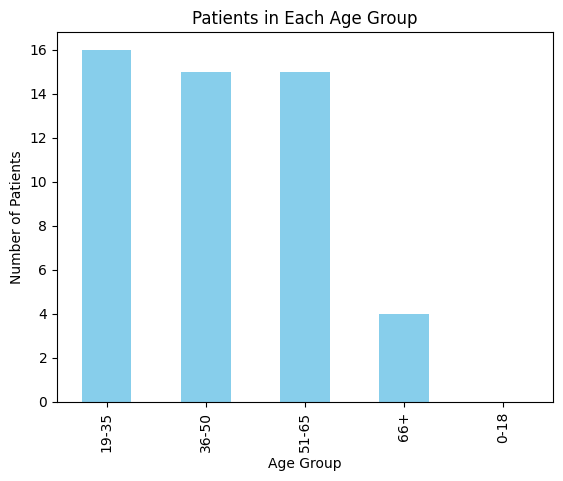

In [21]:
import matplotlib.pyplot as plt

age_group_counts.plot(kind='bar', color='skyblue', title='Patients in Each Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.show()


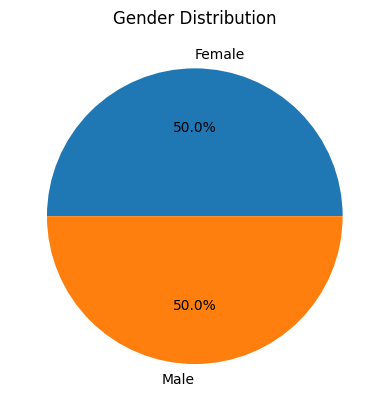

In [22]:
gender_counts.plot(kind='pie', autopct='%1.1f%%', title='Gender Distribution')
plt.ylabel('')  # Hide y-axis label
plt.show()


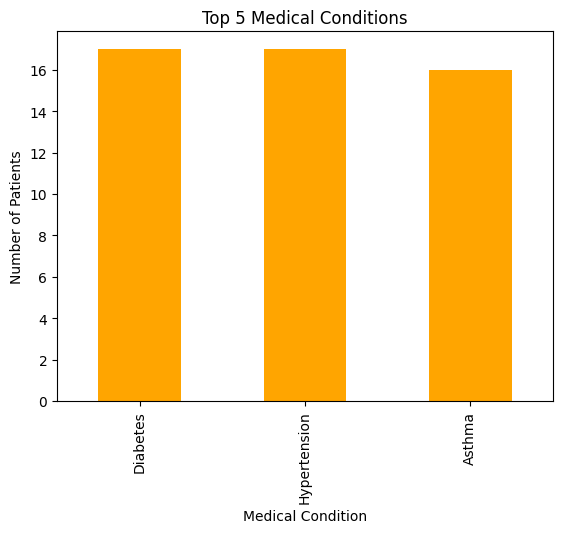

In [23]:
top_conditions = condition_counts.head(5)
top_conditions.plot(kind='bar', color='orange', title='Top 5 Medical Conditions')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.show()


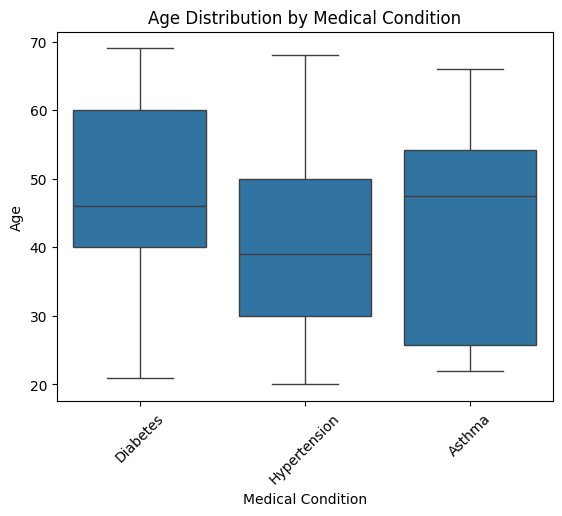

In [25]:
import seaborn as sns

sns.boxplot(x='Condition', y='Age', data=df)
plt.title('Age Distribution by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()


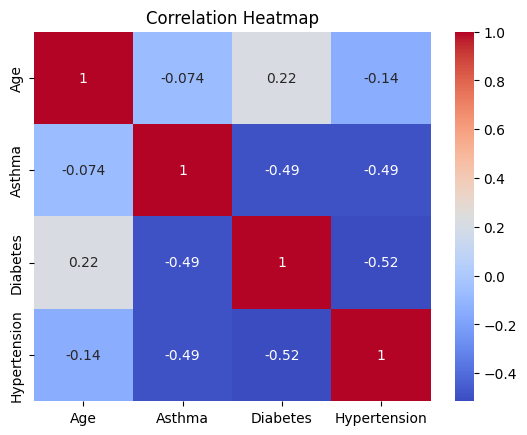

In [26]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [28]:
average_age_per_condition = df.groupby('Condition')['Age'].mean()
print("Average Age for Each Medical Condition:")
print(average_age_per_condition)


Average Age for Each Medical Condition:
Condition
Asthma          42.937500
Diabetes        48.882353
Hypertension    41.588235
Name: Age, dtype: float64


In [29]:
common_condition_encoded = conditions_encoded[most_common_condition]
correlation_with_age = df['Age'].corr(common_condition_encoded)

print(f"Correlation Between Age and {most_common_condition}: {correlation_with_age}")


Correlation Between Age and Diabetes: 0.21796277930587374


In [30]:
condition_by_age_group = df.groupby('AgeGroup')['Condition'].value_counts()
print("Condition Distribution Across Age Groups:")
print(condition_by_age_group)


Condition Distribution Across Age Groups:
AgeGroup  Condition   
0-18      Asthma          0
          Diabetes        0
          Hypertension    0
19-35     Hypertension    7
          Asthma          5
          Diabetes        4
36-50     Hypertension    6
          Diabetes        5
          Asthma          4
51-65     Asthma          6
          Diabetes        6
          Hypertension    3
66+       Diabetes        2
          Asthma          1
          Hypertension    1
Name: count, dtype: int64


C:\Users\gangu\AppData\Local\Temp\ipykernel_10824\3349594199.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_by_age_group = df.groupby('AgeGroup')['Condition'].value_counts()


Value of Detailed Demographic and Condition-Related Data
For Healthcare Providers
Improved Diagnosis and Treatment:
Understanding demographic patterns helps tailor treatments to age, gender, or lifestyle-specific groups.
Patient Risk Profiling:
Enables identification of high-risk populations based on age, gender, or pre-existing conditions.
Resource Allocation:
Efficient distribution of medical resources, staff, and equipment to areas with high prevalence rates of specific conditions.
Health Monitoring:
Tracks trends and flags anomalies in patient health over time, enabling early interventions.
For Researchers
Personalized Medicine Development:
Enables the creation of customized treatment plans considering individual genetic, demographic, and medical condition data.
Identifying Risk Factors:
Helps discover correlations between demographics and diseases, contributing to preventive strategies.
Epidemiological Studies:
Provides insights into disease patterns across regions and populations for public health planning.
Genomic Studies:
Facilitates associations between demographics, genetic predispositions, and conditions for precision medicine research.
For Disease Prevention Programs
Targeted Campaigns:
Focuses awareness and vaccination programs on demographics more prone to specific diseases.
Policy Making:
Informs public health policies tailored to specific communities or age groups.
Early Screening Initiatives:
Promotes screening programs based on demographic data and condition prevalence.
For Clinical Trials
Patient Recruitment:
Ensures diverse representation of participants by targeting specific demographics.
Stratified Analyses:
Allows subgroup analysis based on age, gender, or medical history to study differential treatment effects.
Improved Study Design:
Facilitates trials addressing variations in treatment response among demographic groups.
Regulatory Approvals:
Provides robust evidence of treatment safety and efficacy for diverse populations.
Real-World Benefits
Optimizing Healthcare Systems:
Ensures that healthcare delivery is efficient and equitable.
Reducing Healthcare Costs:
Preventive care and personalized treatments can minimize unnecessary interventions.
Enhanced Patient Satisfaction:
Personalized approaches improve patient trust and compliance with treatment plans.

Age-Specific Prevalence of Conditions

Insight:
Identifies which age groups are more likely to develop specific conditions. For example:
Diabetes prevalence may increase with age.
Asthma might be more common in children or younger adults.
Application:
Helps allocate healthcare resources effectively, such as specialized clinics or awareness campaigns for certain age groups.
Onset Trends of Chronic Diseases

Insight:
Reveals the typical age of onset for conditions like hypertension or Type 2 diabetes.
Application:
Allows healthcare providers to recommend early screening programs for individuals entering higher-risk age brackets.
Co-occurrence of Conditions

Insight:
Highlights which conditions tend to occur together within specific age groups (e.g., hypertension and diabetes in older adults).
Application:
Enables comprehensive care models that address multiple conditions simultaneously.
Impact of Age on Disease Progression

Insight:
Provides data on how diseases progress differently across life stages. For example, asthma in children may improve with age, while diabetes complications may worsen in older adults.
Application:
Guides the creation of age-appropriate treatment and management plans.
Helping Identify At-Risk Populations
Predictive Risk Profiling

Identifies demographic groups with elevated risks based on age-related patterns, such as increased cardiovascular risk in adults over 50.
Facilitates the prioritization of high-risk individuals for preventive care and early interventions.
Customizing Public Health Campaigns

For example, campaigns promoting physical activity to prevent diabetes could target adults aged 30-50, while anti-smoking campaigns for asthma could focus on teenagers.
Screening Recommendations

Develops evidence-based guidelines for regular screening of specific conditions (e.g., mammograms for women above 40, HbA1c tests for adults over 35).
Developing Targeted Interventions
Personalized Treatment Plans

Example: Younger asthma patients may benefit from lifestyle interventions, while older patients may require medication adjustments based on comorbidities.
Behavioral Interventions

Programs for younger populations may focus on education and lifestyle changes, while older adults may require support with medication adherence and mobility.
Vaccination and Preventive Measures

Target specific age groups with vaccines or prevention programs (e.g., flu vaccines for the elderly to prevent complications in those with chronic conditions).
Resource Allocation

Adjust healthcare infrastructure (e.g., pediatric specialists for asthma in children, geriatric services for diabetes-related complications).
Conclusion
Analyzing condition variation across age groups offers actionable insights into disease prevalence, progression, and risk. By tailoring interventions and preventive measures to age-specific needs, healthcare providers and policymakers can significantly enhance health outcomes, reduce healthcare costs, and ensure equitable access to care for all age groups.